In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anonymeter.evaluators import InferenceEvaluator 
import sys
parent_dir = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline"
sys.path.append(parent_dir)
from SynOmics.processing.postprocessing import post_masking

# import logging
# logging.basicConfig(filename="anonymeter_inferences.log", level=logging.DEBUG)

ori = pd.read_csv("OriginalData/integrated_data_final.csv", index_col = 0)
masked_ori = post_masking(ori)
masked_ori.columns = [col.replace('.', '_') for col in masked_ori.columns]

syn_datas = ["synthetic_data_avatars_k5","synthetic_data_avatars_k10","synthetic_data_ctgan","synthetic_data_gauss_copula","synthetic_data_tvae",
             "synthetic_data_synthpop"]
tools = ["AvatarsK5", "AvatarsK10", "CTGAN","GaussianCopula", "TVAE","Synthpop"]
synthetic_dict = {}
for i, tool in enumerate(tools):
    syn_df = pd.read_csv(f"SyntheticData/{syn_datas[i]}.csv", index_col = 0)
    masked_syn_df = post_masking(syn_df)
    masked_syn_df.columns = [col.replace('.', '_') for col in masked_syn_df.columns]
    synthetic_dict[tool] = masked_syn_df

## **1. Singling Out**

In [3]:
import pickle
tools = ["AvatarsK5", "AvatarsK10","CTGAN", "GaussianCopula","TVAE", "Synthpop"]
evaluators = {}
for tool in tools:
    with open(f"evaluator_singling_{tool}.pkl", "rb") as f:
        evaluator_singling_out = pickle.load(f)
    evaluators[tool] = evaluator_singling_out

In [19]:
singlingout_resuls = {}
singlingout_scores = {}
for k, v in evaluators.items():
    risks = []
    scores = []
    for i, v_col in enumerate(v):
        res = v_col.results()
        risk = res.attack_rate.value
        score = 1 - risk
        risks.append(risk)
        scores.append(score)
    singlingout_resuls[k] = risks
    singlingout_scores[k]= scores

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.0038121702307761206, baseline = 0.0038121702307761206. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.0038121702307761206, baseline = 0.005796921549853016. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confidence.py:218: UserWarning: Attack is as good or worse as baseline model. Estimated rates: attack = 0.005796921549853016, baseline = 0.005796921549853016. Analysis results cannot be trusted.
  self._sanity_check()
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/anonymeter/stats/confide

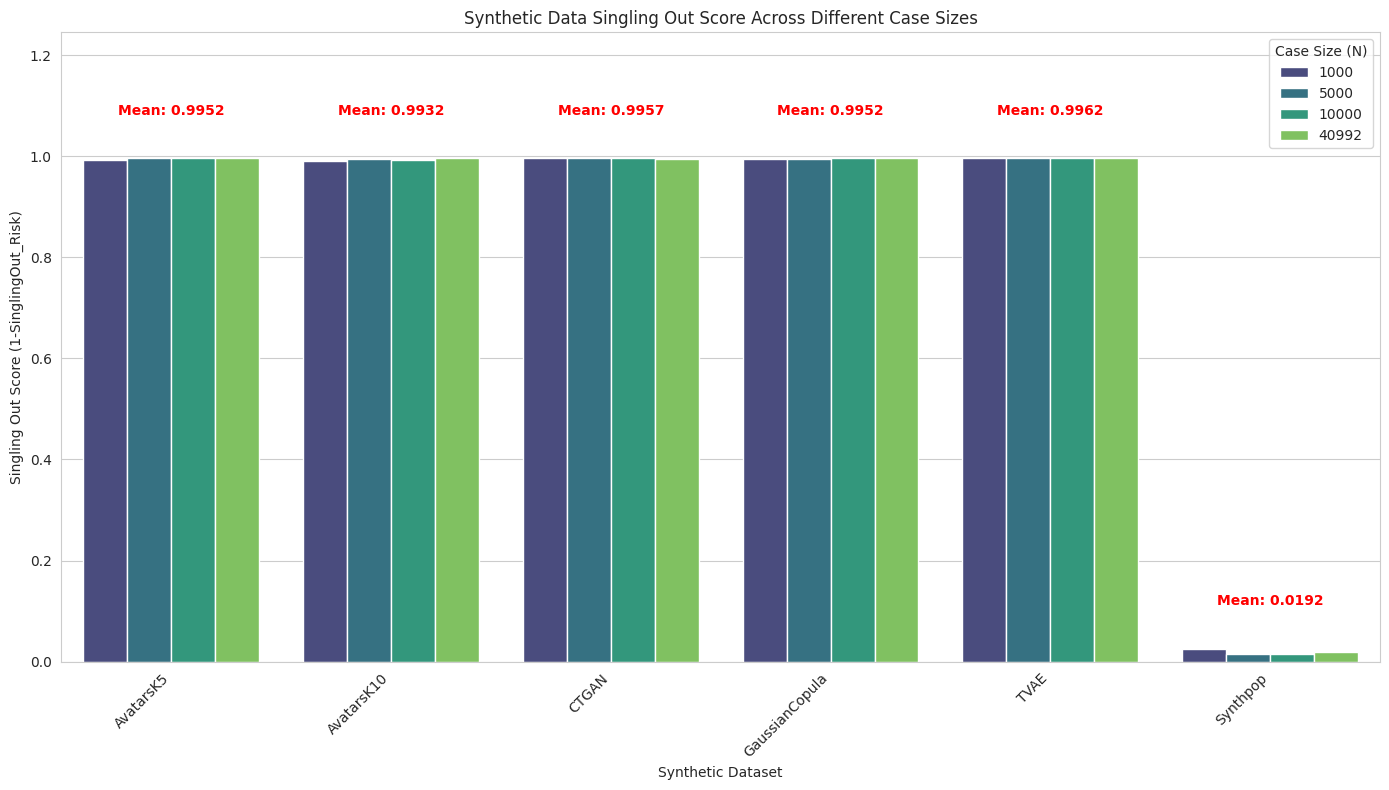

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

# 1. Data Definition

cases = [1000, 5000, 10000, 40992]

# 2. Prepare DataFrame
df = pd.DataFrame(singlingout_scores, index=cases)
df_data_prep = df.reset_index().rename(columns={'index': 'Case'})

# Melt the DataFrame for plotting
df_data_prep['Case'] = df_data_prep['Case'].astype(str)
df_melted = df_data_prep.melt(id_vars='Case', var_name='Model', value_name='Value')

# Round the values for display labels (4 decimal places for clarity)
df_melted['Label'] = df_melted['Value'].apply(lambda x: f'{x:.4f}')

# Define explicit order for cases and models
case_order = ['1000', '5000', '10000', '40992']
model_order = list(singlingout_scores.keys())

# Calculate overall mean for each model for the group label
mean_values = df.mean(axis=0).to_dict()

# --- Plotting ---

# Set figure size and style
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Create the bar plot with explicit order
ax = sns.barplot(x='Model', y='Value', hue='Case', data=df_melted, palette='viridis',
                 hue_order=case_order, order=model_order)

# 3. Add Per-Bar Value Labels
# Create categorical types for proper sorting
case_cat_type = CategoricalDtype(categories=case_order, ordered=True)
model_cat_type = CategoricalDtype(categories=model_order, ordered=True)

df_melted['Case_ordered'] = df_melted['Case'].astype(case_cat_type)
df_melted['Model_ordered'] = df_melted['Model'].astype(model_cat_type)

# Sort by Case (hue) then Model (x) to match seaborn's bar order
df_sorted = df_melted.sort_values(by=['Case_ordered', 'Model_ordered']).reset_index(drop=True)
labels = df_sorted['Label'].tolist()

if len(labels) == len(ax.patches):
    for p, label in zip(ax.patches, labels):
        # Only annotate if the value is not zero
        if p.get_height() > 0:
            ax.annotate(label,
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=8, color='black',
                        xytext=(0, 5),
                        textcoords='offset points',
                        rotation=90)

# 4. Add Overall Model Mean Label (with increased vertical position)
model_positions = {model: i for i, model in enumerate(model_order)}

# *** MODIFICATION START ***
new_buffer_factor = 0.08  # Increased buffer to move the mean label higher
# *** MODIFICATION END ***

for model, mean_val in mean_values.items():
    x_pos = model_positions[model]
    # Find the top of the highest bar in this model's group
    max_height = df_melted[df_melted['Model'] == model]['Value'].max()
    
    # Calculate y_pos with the increased buffer
    y_pos = max_height + new_buffer_factor * df_melted['Value'].max() 

    # Annotate the mean value for the model
    ax.annotate(f'Mean: {mean_val:.4f}',
                (x_pos, y_pos),
                ha='center', va='bottom',
                fontsize=10, color='red',
                fontweight='bold')


# 5. Set titles, labels, and save
plt.title('Synthetic Data Singling Out Score Across Different Case Sizes')
plt.xlabel('Synthetic Dataset')
plt.ylabel('Singling Out Score (1-SinglingOut_Risk)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Case Size (N)')

# *** MODIFICATION START ***
# Adjust y-limit to accommodate the new, higher mean labels.
plt.ylim(0, df_melted['Value'].max() * 1.25) 
# *** MODIFICATION END ***

plt.tight_layout()

plt.savefig('Singlingout_Score_bar_plot_with_mean_high.png')

## **2. Inference**

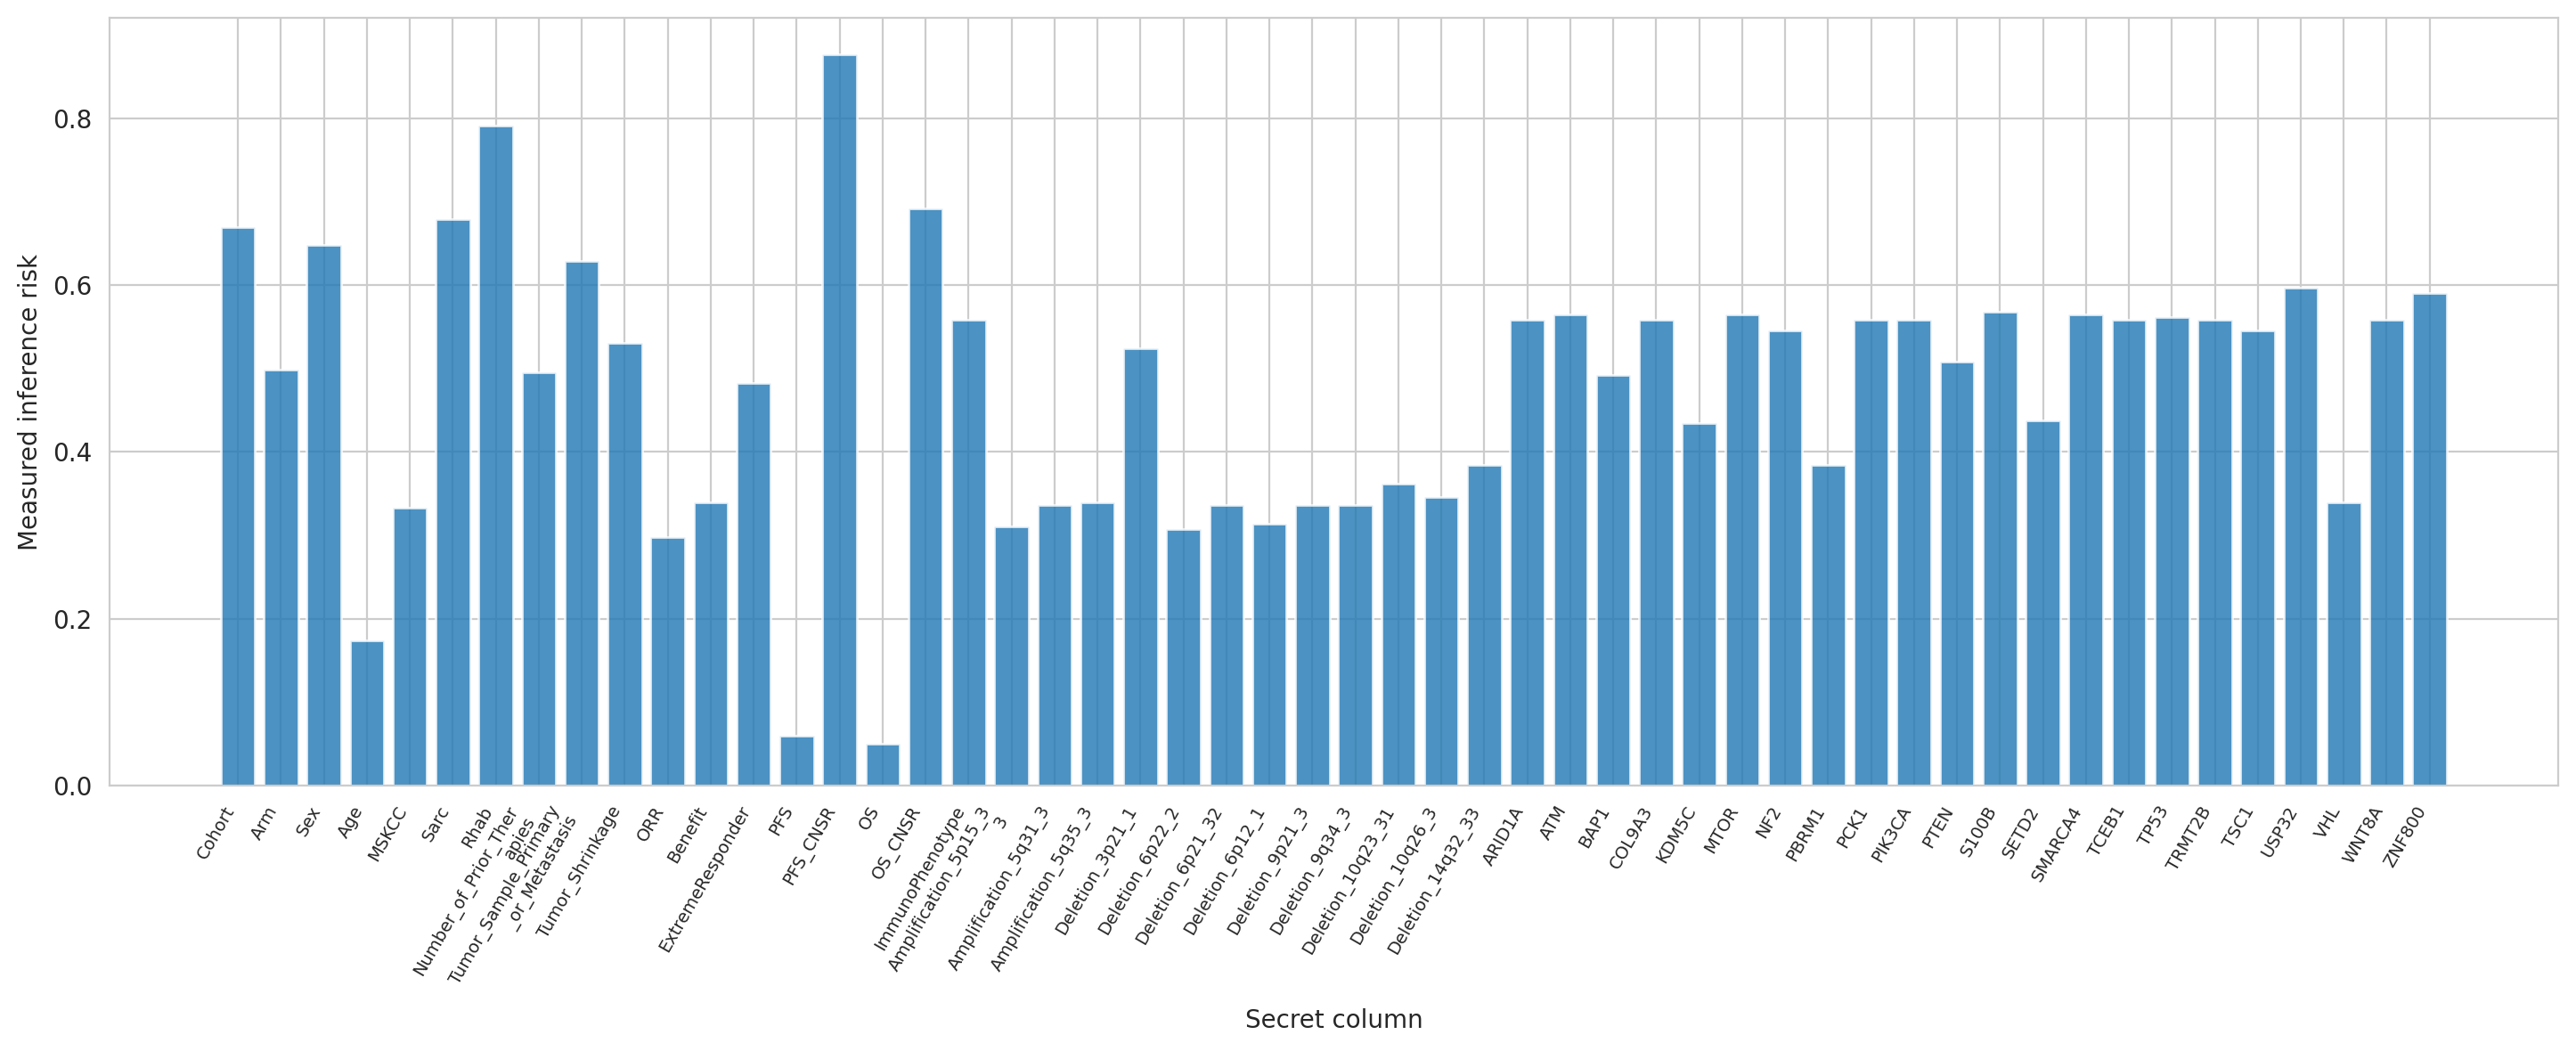

In [22]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import textwrap

with open("results_inferences.pkl", "rb") as f:
    results_inferences = pickle.load(f)



# data
results = results_inferences["Synthpop"]
risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

# Optional: wrap long labels so they occupy multiple lines
wrapped = [ "\n".join(textwrap.wrap(lbl, 20)) for lbl in columns ]

# Dynamic figure width: scale with number of bars
n = len(columns)
fig_w = max(10, n * 0.28)    # tweak the multiplier to taste
fig_h = 6

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)  # higher DPI for quality
x = np.arange(n)
ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(wrapped, rotation=60, ha='right', fontsize=7)
ax.set_ylabel("Measured inference risk")
ax.set_xlabel("Secret column")

plt.tight_layout()   # ensure labels are not cut off

# Save high-res copy
# plt.savefig("inference_risk_synthpop.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_2525353/1084093547.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4, color=plt.cm.get_cmap('viridis')(i/n_datasets))
/tmp/ipykernel_2525353/1084093547.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4, color=plt.cm.get_cmap('viridis')(i/n_datasets))
/tmp/ipykernel_2525353/1084093547.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
 

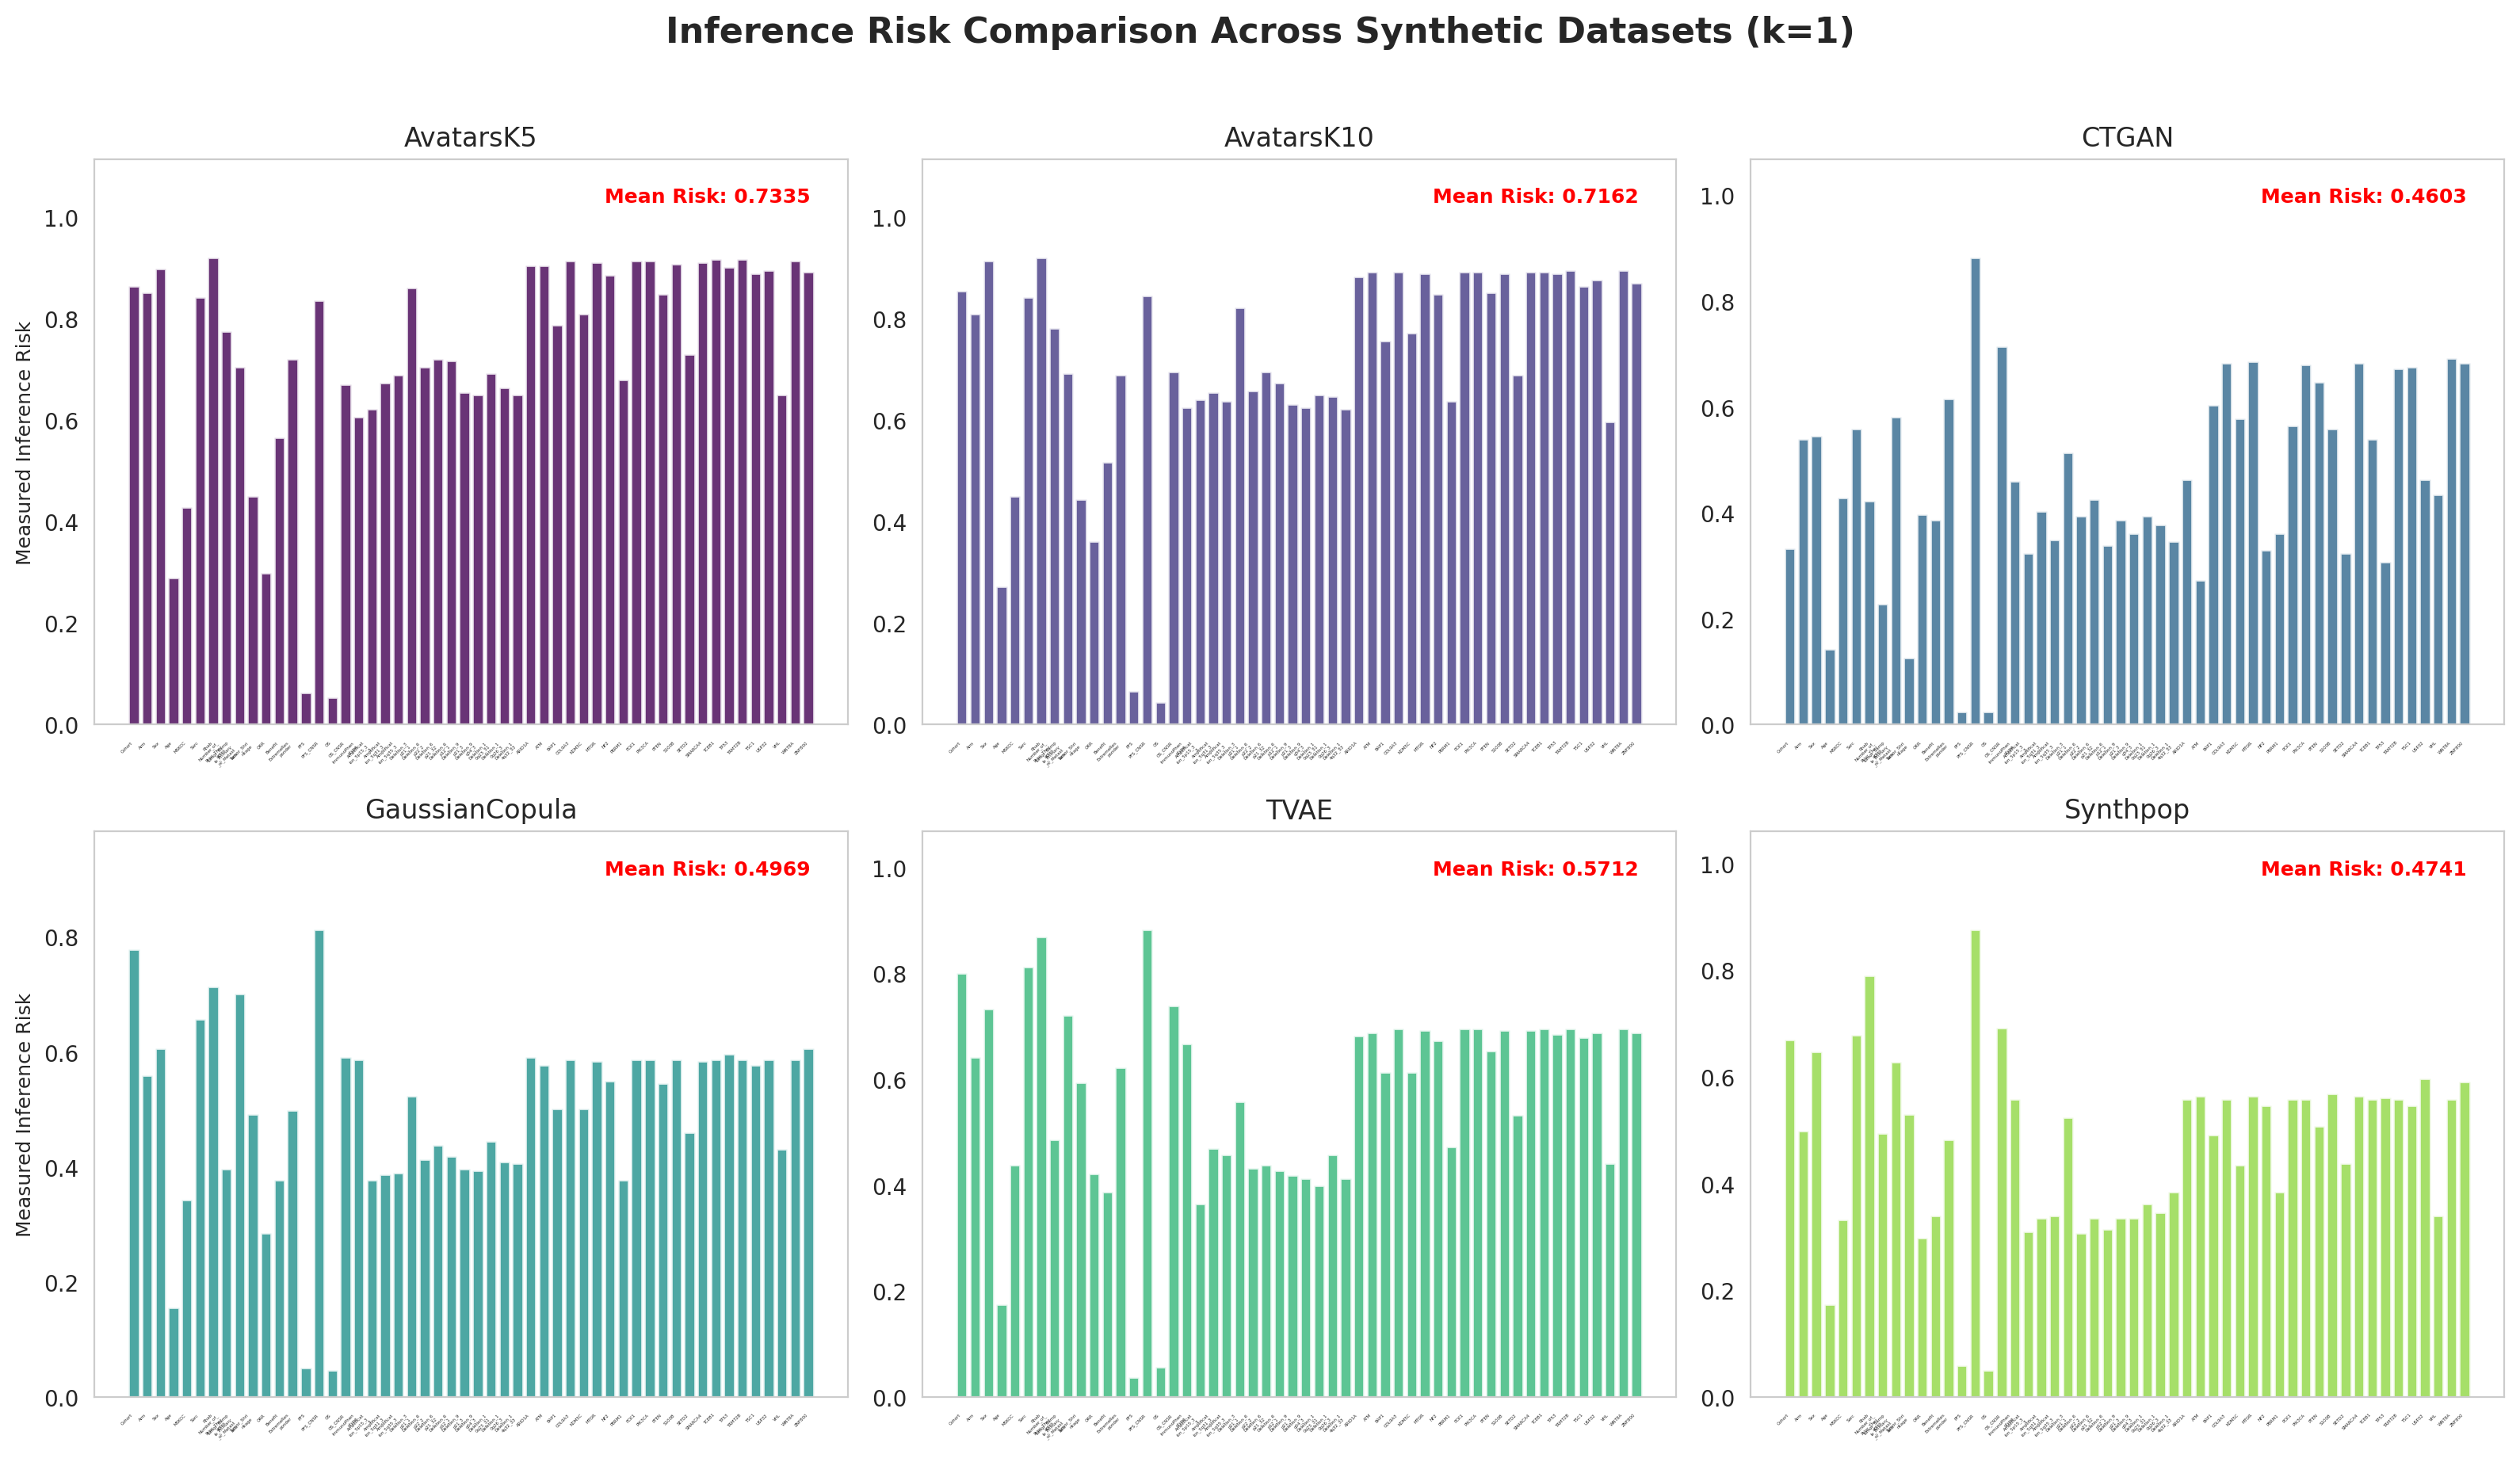

In [28]:
##### import pickle
import matplotlib.pyplot as plt
import numpy as np
import textwrap


with open("results_inferences.pkl", "rb") as f:
    results_inferences = pickle.load(f)

# --- Subplot Configuration ---
datasets = list(results_inferences.keys())
n_datasets = len(datasets)
if n_datasets != 6:
    print(f"Warning: Expected 6 datasets, found {n_datasets}. Adjusting subplot grid.")

# Grid setup
n_rows = 2
n_cols = 3
fig_w = 16  # Overall figure width
fig_h = 9   # Overall figure height

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), dpi=200)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration


for i, dataset_name in enumerate(datasets):
    # 1. Select Data
    results = results_inferences[dataset_name]
    risks = [res[1].risk().value for res in results]
    columns = [res[0] for res in results]
    
    # 2. Get the current subplot axis
    ax = axes[i]
    
    # 3. Calculate Mean Risk
    mean_risk = np.mean(risks)

    # 4. Prepare Labels
    wrapped = ["\n".join(textwrap.wrap(lbl, 10)) for lbl in columns] # Shorter wrap for subplots
    
    # 5. Plot Bars
    x = np.arange(len(columns))
    ax.bar(x, risks, alpha=0.8, ecolor='black', capsize=4, color=plt.cm.get_cmap('viridis')(i/n_datasets))
    
    # 6. Set Titles, Labels, and Ticks
    ax.set_title(f"{dataset_name}", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(wrapped, rotation=45, ha='right', fontsize=2)
    
    # Set Y-axis label only for the left column plots
    if i % n_cols == 0:
        ax.set_ylabel("Measured Inference Risk", fontsize=9)
    else:
        # Keep y-label clear for other plots but ensure scales are consistent (optional, depending on data)
        # ax.tick_params(labelleft=False) 
        pass 

    # 7. Add Mean Value Annotation
    # Determine annotation position (top right corner of the plot)
    y_lim_max = max(risks) * 1.1 if risks else 1.0 # Max height with 10% buffer
    x_pos = len(columns) - 1 # Position above the last bar
    
    # Set Y-limit to ensure consistency and space for annotation
    ax.set_ylim(0, y_lim_max * 1.1)
    
    # Text position: use an absolute position relative to the axes
    ax.text(0.95, 0.95, 
            f'Mean Risk: {mean_risk:.4f}', 
            transform=ax.transAxes, # Use axis coordinates (0 to 1)
            fontsize=9, 
            color='red', 
            fontweight='bold', 
            ha='right', va='top', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    ax.grid(False)
# Remove any unused subplots if n_datasets < n_rows * n_cols
for j in range(n_datasets, n_rows * n_cols):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap, especially with rotated x-labels
plt.suptitle("Inference Risk Comparison Across Synthetic Datasets (k=1)", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 1]) 

# Save high-res copy
plt.savefig("inference_risk_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
n_cols = 10
DATA_IDENTIFIER_COLUMN = 'Source'

syn_df_proto = synthetic_dict["Synthpop"].iloc[:,1000:1000+n_cols]
syn_df_proto[DATA_IDENTIFIER_COLUMN] = 'Synthetic Data'

ori_df_proto = masked_ori.iloc[:,1000:1000+n_cols]
ori_df_proto[DATA_IDENTIFIER_COLUMN] = 'Original Data'

combined_df = pd.concat([ori_df_proto, syn_df_proto], ignore_index=True)
FEATURES_TO_COMPARE = ori_df_proto.columns.tolist()
# Remove any features from the list that might not exist in the combined dataframe
if DATA_IDENTIFIER_COLUMN in FEATURES_TO_COMPARE:
    print(f"⚠️ Warning: The identifier column '{DATA_IDENTIFIER_COLUMN}' was in the feature list and has been removed.")
    FEATURES_TO_COMPARE.remove(DATA_IDENTIFIER_COLUMN)

⚠️ Warning: The identifier column 'Source' was in the feature list and has been removed.


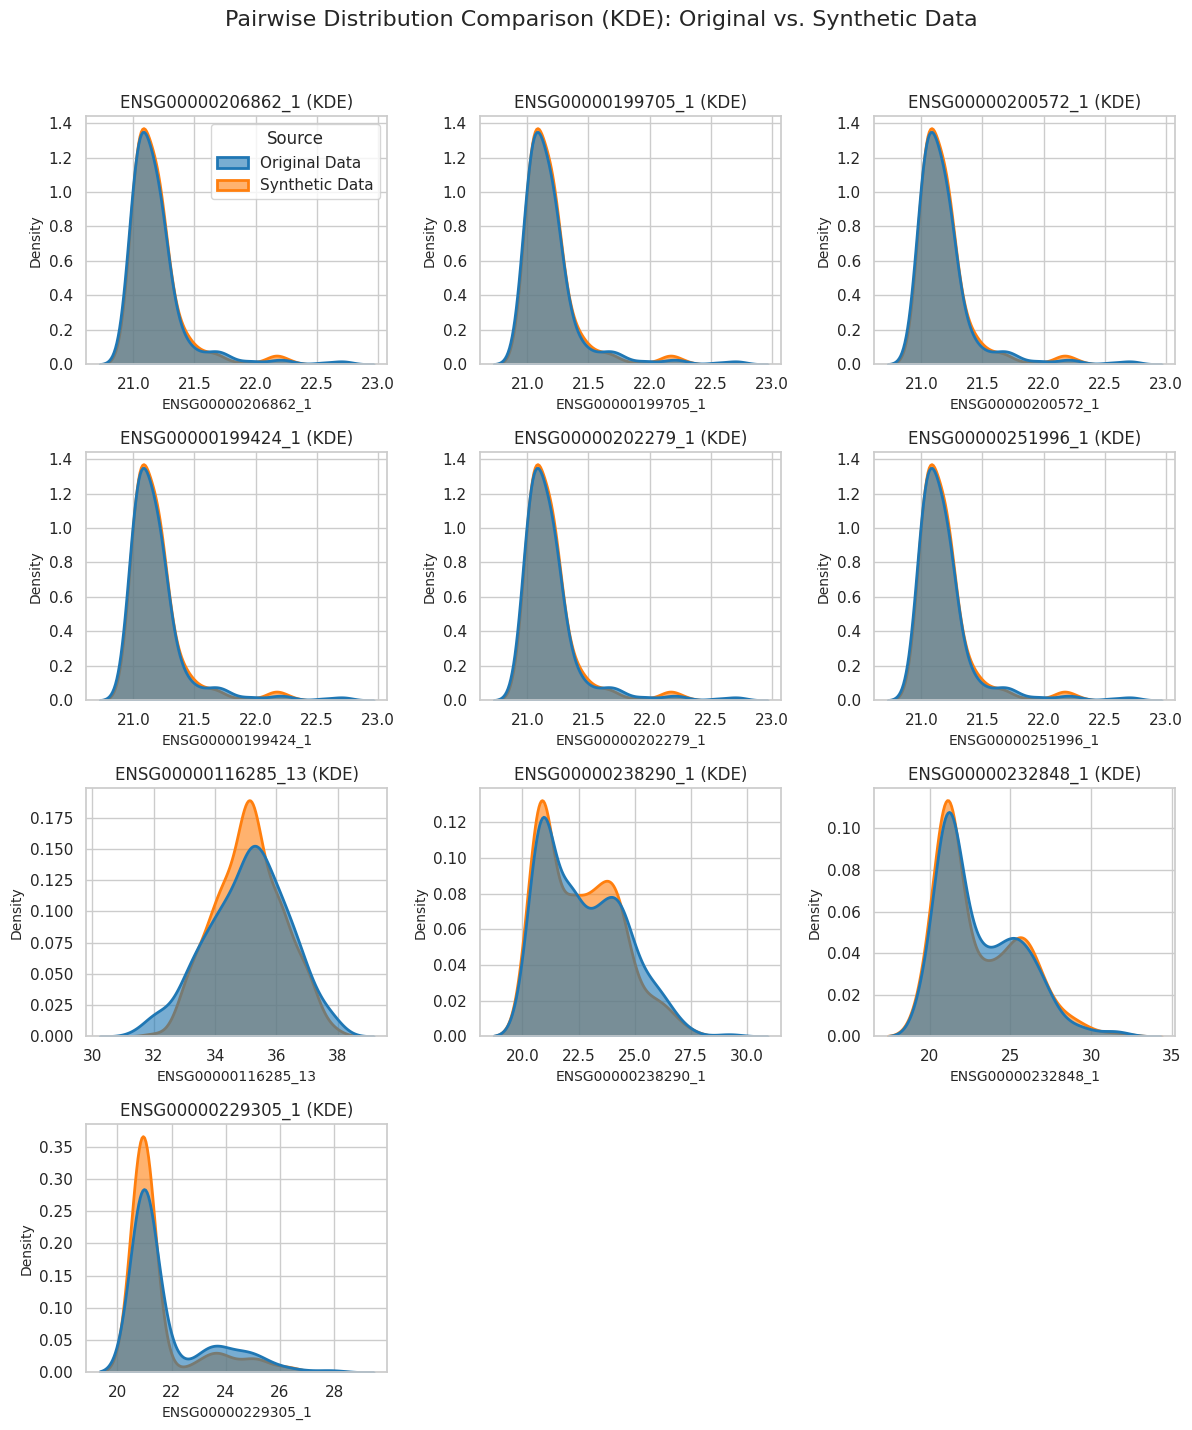

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have loaded and combined your dataframes into 'combined_df'
# with a column named 'Source' and defined your list 'FEATURES_TO_COMPARE'.

# --- 3. Plotting the Comparisons using KDEPLOT ---

sns.set_theme(style="whitegrid")
num_features = len(FEATURES_TO_COMPARE)

# Determine the grid layout (e.g., 5 features -> 2x3 grid)
n_cols = 3
n_rows = int(np.ceil(num_features / n_cols))

# Create the figure and axes
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows) # Dynamic figure sizing
)

# Flatten the axes array for easy indexing, even if n_rows=1
axes = axes.flatten()

# Loop through the features and plot the comparison on each subplot
for i, feature in enumerate(FEATURES_TO_COMPARE):
    # *** CHANGE IS HERE: Use sns.kdeplot() instead of sns.histplot() ***
    sns.kdeplot(
        data=combined_df,
        x=feature,
        hue='Source',              # The key parameter for comparison
        ax=axes[i],
        palette=['#1f77b4', '#ff7f0e'], # Consistent colors
        alpha=0.6,
        fill=True,                 # Fills the area under the curve
        linewidth=2
    )
    
    # Set titles and labels
    axes[i].set_title(f'{feature} (KDE)', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    
    # Only show the legend on the first plot for clarity
    if i > 0:
        # Check if the legend exists before trying to remove it
        if axes[i].get_legend() is not None:
             axes[i].get_legend().remove()

# Hide any unused subplots if num_features is less than n_rows * n_cols
for j in range(num_features, n_rows * n_cols):
    fig.delaxes(axes[j])

# Adjust spacing and add a main title
plt.suptitle('Pairwise Distribution Comparison (KDE): Original vs. Synthetic Data', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
n_cols = 10
DATA_IDENTIFIER_COLUMN = 'Source'

syn_df_proto = synthetic_dict["GaussianCopula"].iloc[:,1000:1000+n_cols]
syn_df_proto[DATA_IDENTIFIER_COLUMN] = 'Synthetic Data'

ori_df_proto = masked_ori.iloc[:,1000:1000+n_cols]
ori_df_proto[DATA_IDENTIFIER_COLUMN] = 'Original Data'

combined_df = pd.concat([ori_df_proto, syn_df_proto], ignore_index=True)
FEATURES_TO_COMPARE = ori_df_proto.columns.tolist()
# Remove any features from the list that might not exist in the combined dataframe
if DATA_IDENTIFIER_COLUMN in FEATURES_TO_COMPARE:
    print(f"⚠️ Warning: The identifier column '{DATA_IDENTIFIER_COLUMN}' was in the feature list and has been removed.")
    FEATURES_TO_COMPARE.remove(DATA_IDENTIFIER_COLUMN)

⚠️ Warning: The identifier column 'Source' was in the feature list and has been removed.


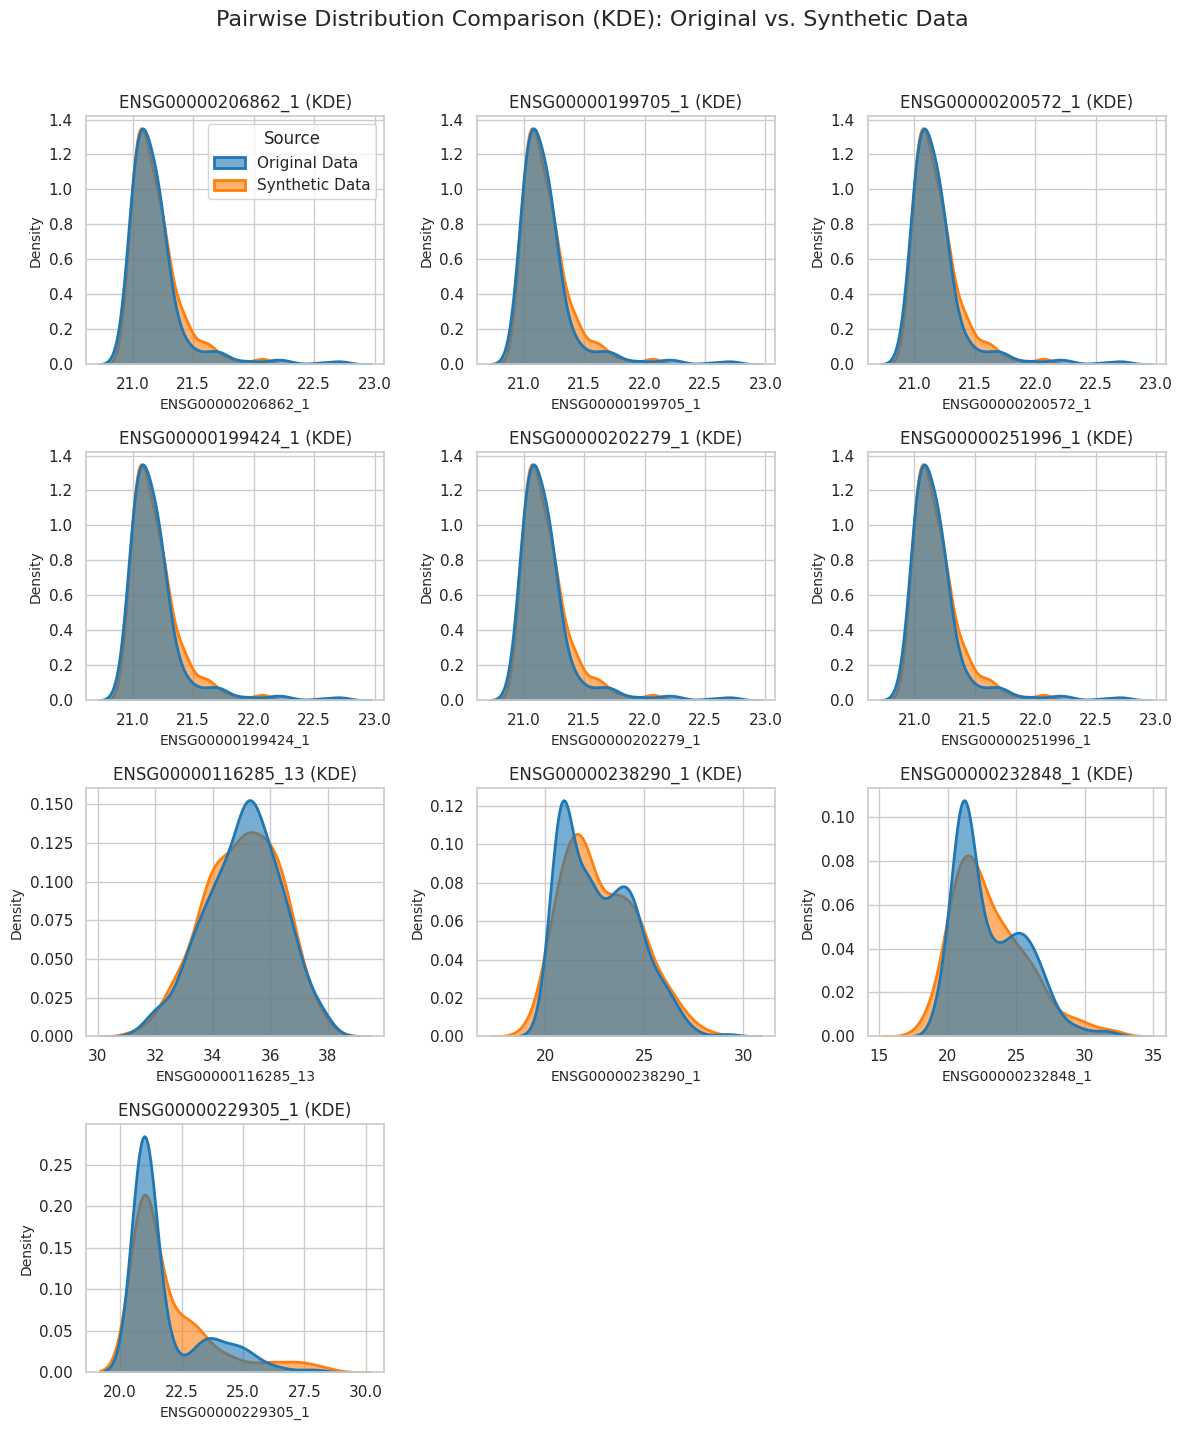

In [27]:

# --- 3. Plotting the Comparisons using KDEPLOT ---

sns.set_theme(style="whitegrid")
num_features = len(FEATURES_TO_COMPARE)

# Determine the grid layout (e.g., 5 features -> 2x3 grid)
n_cols = 3
n_rows = int(np.ceil(num_features / n_cols))

# Create the figure and axes
fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows) # Dynamic figure sizing
)

# Flatten the axes array for easy indexing, even if n_rows=1
axes = axes.flatten()

# Loop through the features and plot the comparison on each subplot
for i, feature in enumerate(FEATURES_TO_COMPARE):
    # *** CHANGE IS HERE: Use sns.kdeplot() instead of sns.histplot() ***
    sns.kdeplot(
        data=combined_df,
        x=feature,
        hue='Source',              # The key parameter for comparison
        ax=axes[i],
        palette=['#1f77b4', '#ff7f0e'], # Consistent colors
        alpha=0.6,
        fill=True,                 # Fills the area under the curve
        linewidth=2
    )
    
    # Set titles and labels
    axes[i].set_title(f'{feature} (KDE)', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    
    # Only show the legend on the first plot for clarity
    if i > 0:
        # Check if the legend exists before trying to remove it
        if axes[i].get_legend() is not None:
             axes[i].get_legend().remove()

# Hide any unused subplots if num_features is less than n_rows * n_cols
for j in range(num_features, n_rows * n_cols):
    fig.delaxes(axes[j])

# Adjust spacing and add a main title
plt.suptitle('Pairwise Distribution Comparison (KDE): Original vs. Synthetic Data', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()